# 📊 Trabalho Final: Análise de Fatores Salariais em Empresa Multinacional

**Aluno:** Fabio Kishino  
**Data:** Setembro 2025

## 🎯 Tema de Estudo

O problema central deste trabalho é compreender quais fatores influenciam o salário dos profissionais em uma empresa multinacional de tecnologia. Em particular, busca-se investigar de que forma variáveis como o regime de trabalho (on-site vs. remoto), o tempo de experiência profissional, o país de atuação e o departamento influenciam na remuneração. <br>

---

### 📈 Fonte de Dados

A fonte utilizada é o dataset público **"HR Data MNC"**, disponibilizado no portal [Kaggle](https://www.kaggle.com/datasets/rohitgrewal/hr-data-mnc).

A base contém informações abrangentes de funcionários, incluindo variáveis como:
- Salário anual
- Anos de experiência
- Localização geográfica
- Regime de trabalho (on-site ou remoto)
- Departamento de atuação
- Outros atributos relevantes

---
## 🔍 Objetivos da Análise

O foco da análise é **explorar a relação entre características profissionais e geográficas com a variável salário**. Especificamente, pretende-se:

### Objetivos Específicos

1. **📍 Regime de Trabalho**  
   Comparar o impacto do regime de trabalho on-site versus remoto na remuneração

2. **⏱️ Experiência Profissional**  
   Analisar como o tempo de experiência influencia o salário

3. **🌍 Análise Geográfica**  
   Extrair o país da variável de localização para identificar os países com maior média salarial

4. **🏢 Departamentos**  
   Avaliar como o departamento de atuação do profissional se relaciona com os níveis de remuneração

> **Resultado Esperado:** Esses pontos permitirão identificar padrões salariais relevantes e fornecer uma visão abrangente dos fatores determinantes para a remuneração.

---

## 🛠️ Metodologia

Para alcançar os objetivos, serão aplicadas **técnicas de mineração de dados** contemplando as seguintes etapas:

1. 📊 Análise Exploratória de Dados (EDA)
- Estatísticas descritivas
- Visualizações interativas
- Análise de correlações entre variáveis

2. 🔧 Pré-processamento e Transformação
- Tratamento de valores ausentes
- Normalização de variáveis
- Conversão de unidades monetárias

3. 🤖 Técnicas de Classificação e Regressão
- **Regressão Linear Múltipla:** para mensurar influência linear das variáveis

4. 📋 Visualização de Resultados
- Gráficos

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('../../data-sets/HR_Data_MNC_Data Science Lovers.csv')
df

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


In [23]:
# Querying only Active employees and creating a copy to avoid warnings
df = df.query("Status == 'Active'").copy()

In [24]:
# Verificando se existem valores nulos
df.isnull().any()

Unnamed: 0            False
Employee_ID           False
Full_Name             False
Department            False
Job_Title             False
Hire_Date             False
Location              False
Performance_Rating    False
Experience_Years      False
Status                False
Work_Mode             False
Salary_INR            False
dtype: bool

In [25]:
import requests

def get_inr_to_brl_rate():
    try:
        response = requests.get('https://api.exchangerate-api.com/v4/latest/INR')
        data = response.json()
        return data['rates']['BRL']
    except:
        return None

# Get rate once and apply to entire column
rate = get_inr_to_brl_rate()
if rate:
    df.loc[:, 'Salary_INR'] = round(((df['Salary_INR'] * rate)/12), 2)

/var/folders/np/801w6bmj0d78pf0s_9hln43h0000gn/T/ipykernel_89660/2911462890.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4316.13 7281.51 5044.26 ... 5244.97 6685.79 5059.68]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Salary_INR'] = round(((df['Salary_INR'] * rate)/12), 2)


In [26]:
# Rename Salary_INR column to Salary_BRL
df = df.rename(columns={'Salary_INR': 'Salary_BRL'})
df

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_BRL
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,4316.13
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,7281.51
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,5044.26
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,2724.46
5,5,EMP0000006,Jason Gardner,Operations,Logistics Coordinator,2021-02-23,"Zimmermanstad, Bulgaria",5,4,Active,On-site,3265.76
...,...,...,...,...,...,...,...,...,...,...,...,...
1999994,1999994,EMP1999995,Mrs. Denise Jones,Sales,Sales Director,2012-02-19,"Simpsonberg, Uganda",1,13,Active,Remote,2293.59
1999995,1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,3348.52
1999996,1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,5244.97
1999997,1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,6685.79


Média Salarial Por modo de trabalho (Remoto e Presencial):
  Work_Mode   Salary_BRL
0   On-site  4566.263963
1    Remote  4567.306628


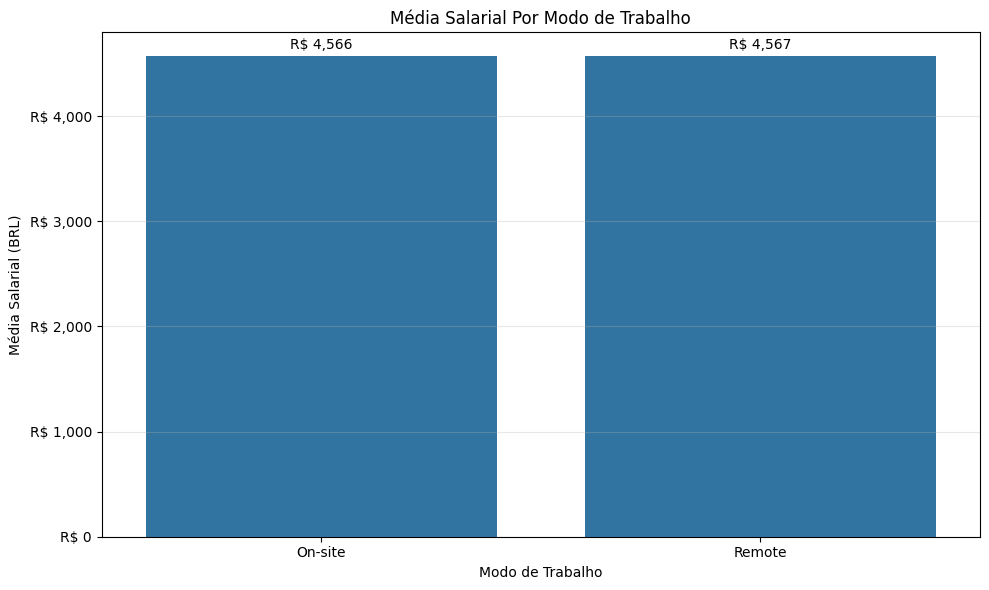

In [34]:
# Gráfico para comparar a média entre os modos de trabalho On-Site e Remoto
import matplotlib.pyplot as plt
import seaborn as sns

# Calculo da média salarial por modo de trabalho
salary_by_work_mode = df.groupby('Work_Mode')['Salary_BRL'].mean().reset_index()
print("Média Salarial Por modo de trabalho (Remoto e Presencial):")
print(salary_by_work_mode)

# Gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=salary_by_work_mode, x='Work_Mode', y='Salary_BRL')

# Adicionar valores nas barras
for i, v in enumerate(salary_by_work_mode['Salary_BRL']):
    ax.text(i, v + (v * 0.01), f'R$ {v:,.0f}', ha='center', va='bottom')

plt.title('Média Salarial Por Modo de Trabalho')
plt.xlabel('Modo de Trabalho')
plt.ylabel('Média Salarial (BRL)')
plt.grid(axis='y', alpha=0.3)

# Format y-axis to show currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

### Gráfico 01

De modo geral, o modo de trabalho nao apresenta diferença significativa no salário, mas é preciso ir mais afundo para obter conclusões mais precisas.

In [45]:
# Analisar Diferenças Salariais do setor de IT com base no modo de trabalho (Remoto e Presencial)
print(df['Department'].unique())

# Filtrar dados apenas do setor de IT
for department in df['Department'].unique():
  df_dp = df[df['Department'] == department]

  # Calcular a média salarial por modo de trabalho
  salary_by_work_mode_dp = df_dp.groupby('Work_Mode')['Salary_BRL'].mean().reset_index()
  print(f"Média Salarial Por modo de trabalho (Remoto e Presencial) - {department}:")
  print(salary_by_work_mode_dp)

['Marketing' 'HR' 'IT' 'Operations' 'Finance' 'Sales' 'R&D']
Média Salarial Por modo de trabalho (Remoto e Presencial) - Marketing:
  Work_Mode   Salary_BRL
0   On-site  3917.523756
1    Remote  3917.369214
Média Salarial Por modo de trabalho (Remoto e Presencial) - HR:
  Work_Mode   Salary_BRL
0   On-site  3788.959096
1    Remote  3788.635907
Média Salarial Por modo de trabalho (Remoto e Presencial) - IT:
  Work_Mode   Salary_BRL
0   On-site  5750.153179
1    Remote  5752.239635
Média Salarial Por modo de trabalho (Remoto e Presencial) - Operations:
  Work_Mode   Salary_BRL
0   On-site  3848.142415
1    Remote  3839.354238
Média Salarial Por modo de trabalho (Remoto e Presencial) - Finance:
  Work_Mode   Salary_BRL
0   On-site  4782.777118
1    Remote  4802.773979
Média Salarial Por modo de trabalho (Remoto e Presencial) - HR:
  Work_Mode   Salary_BRL
0   On-site  3788.959096
1    Remote  3788.635907
Média Salarial Por modo de trabalho (Remoto e Presencial) - IT:
  Work_Mode   Salary_